- 北京大学金融工程实验室《人工智能与财务分析》课件

## 一、财务数据基础



In [3]:
# 导入相应模块

import pandas as pd
import matplotlib.pyplot as plt
import pkufinlab as pku
rq=pku.rq_init()

### 1. 获取财务报表信息

在股票相关的量化策略中，尤其是量化基本面及多因子模型下的量化策略会非常多的用于上市公司的财务数据。而财务数据的分析，离不开财务上三张表的理解和分析。因而基本面量化策略做得好不好，更多的会取决于对于财务报表间不同科目关系的理解是否深入。

参考数据链接 [RiceQuant说明: 查询季度财务信息](https://www.ricequant.com/doc/rqdata/python/stock-mod.html#get-pit-financials-ex-%E6%9F%A5%E8%AF%A2%E5%AD%A3%E5%BA%A6%E8%B4%A2%E5%8A%A1%E4%BF%A1%E6%81%AF) <br />

一般使用以下函数调用数据：

- get_factor(order_book_ids, factor, start_date, end_date, universe=None) 
- get_pit_financials_ex(fields, start_quarter,end_quarter，order_book_ids=None, date=None, statements=None, market='cn')
- 或者 get_financials(query, quarter, interval=None, expect_df=False) （退役中）
- 或者 get_fundamentals(query, entry_date, interval=None, report_quarter=False, expect_df=False)（退役中）

#### 资产负债表

In [15]:
# 先看一下原始报表数据的情况
rq.get_pit_financials_ex(fields=["total_assets", "bill_accts_receivable"], 
                         start_quarter='2018q2', end_quarter='2021q1',
                         order_book_ids=["300750.XSHE"],statements='all').iloc[::-1]

info_date  if_adjusted  total_assets  \
order_book_id quarter                                         
300750.XSHE   2021q1  2021-04-30            0  1.733289e+11   
              2020q4  2021-04-28            0  1.566184e+11   
              2020q3  2021-10-28            1  1.377689e+11   
              2020q3  2020-10-28            0  1.377689e+11   
              2020q2  2021-08-26            1  1.000371e+11   
              2020q2  2020-08-27            0  1.000371e+11   
              2020q1  2021-04-30            1  1.014365e+11   
              2020q1  2020-04-28            0  1.014365e+11   
              2019q4  2021-04-28            1  1.013792e+11   
              2019q4  2020-04-25            0  1.013520e+11   
              2019q3  2020-10-28            1  9.631136e+10   
              2019q3  2019-10-26            0  9.631136e+10   
              2019q2  2020-08-27            1  8.988863e+10   
              2019q2  2019-08-24            0  8.988863e+10   
              2019q1  2020-04-28            1  8.410127e+10   
              2019q1  2019-04-27            0  8.410127e+10   
              2018q4  2021-04-28            1  7.388370e+10   
              2018q4  2020-04-25            1  7.388370e+10   
              2018q4  2019-04-25            0  7.388370e+10   
              2018q3  2019-10-26            1  6.379061e+10   
              2018q3  2018-10-26            0  6.379061e+10   
              2018q2  2019-08-24            1  5.544399e+10   
              2018q2  2018-08-24            0  5.544399e+10   

                       bill_accts_receivable  
order_book_id quarter                         
300750.XSHE   2021q1            2.170816e+10  
              2020q4            2.117068e+10  
              2020q3            1.583944e+10  
              2020q3            1.583944e+10  
              2020q2            1.316336e+10  
              2020q2            1.316336e+10  
              2020q1            1.480278e+10  
              2020q1            1.480278e+10  
              2019q4            1.798849e+10  
              2019q4            1.798849e+10  
              2019q3            1.841109e+10  
              2019q3            1.841109e+10  
              2019q2            1.763800e+10  
              2019q2            1.763800e+10  
              2019q1            1.709585e+10  
              2019q1            1.709585e+10  
              2018q4            1.596775e+10  
              2018q4            1.596775e+10  
              2018q4            1.596775e+10  
              2018q3            1.395476e+10  
              2018q3            1.395476e+10  
              2018q2            1.109996e+10  
              2018q2            1.109996e+10

在上述数据中可以看到，在处理报表数据时需注意几个问题：

- 报表公告日：报表的报告日是每个季度的最后一天，而报表的报露日期却往往在一两个月之后； 
- 报表修正：历史报表数据有可能会在后期回过来进行修改； 

因而，在读取报表数据时，往往需要细致的数据清洗工作，确保读取到的数据都是在当天可以获取（point-in-time)的数据，而不是读到未披露或后期进行修改后的数据。

在米筐的get_factor函数中，对相应的问题做了处理，也即在每一个交易日，只返回在当天能获取到的最新的财务数据。为了更好的集中于对模型和算法的理解，我们后面会直接通过get_factor函数来进行财务数据的提取。

In [16]:
# 案例 获取宁德时代的资产负债表信息
from datetime import datetime


start_date = "2018-06-11"
end_date = datetime.now().strftime("%Y-%m-%d")

# 获取资产负债表数据
ND_asset = rq.get_factor("300750.XSHE", ["total_assets", "bill_accts_receivable"], start_date, end_date)
ND_asset = ND_asset.reset_index(level=(0)).drop(columns=["order_book_id"])
ND_asset

,total_assets,bill_accts_receivable
date,,
2018-06-11,4.782324e+10,1.424344e+10
2018-06-12,4.782324e+10,1.424344e+10
2018-06-13,4.782324e+10,1.424344e+10
2018-06-14,4.782324e+10,1.424344e+10
2018-06-15,4.782324e+10,1.424344e+10
...,...,...
2022-02-24,2.491518e+11,2.020370e+10
2022-02-25,2.491518e+11,2.020370e+10
2022-02-28,2.491518e+11,2.020370e+10


如果需直接对财务数据进行相关计算，那么就需对每一个交易日到底能够获取的历史财务数据进行提取，在进行日期对齐后再进行相关运算。在米筐的get_factor函数中，提供了比较方便的XXX_mrq_n方式对历史财务数据进行提取。

In [17]:
# 计算资产负债表相关指标
df_ND = rq.get_factor("300750.XSHE", ["bill_accts_receivable","bill_accts_receivable_mrq_0","bill_accts_receivable_mrq_1","bill_accts_receivable_mrq_4"], start_date, end_date)
df_ND.iloc[::-1]

bill_accts_receivable  bill_accts_receivable_mrq_0  \
order_book_id date                                                             
300750.XSHE   2022-03-02           2.020370e+10                 2.020370e+10   
              2022-03-01           2.020370e+10                 2.020370e+10   
              2022-02-28           2.020370e+10                 2.020370e+10   
              2022-02-25           2.020370e+10                 2.020370e+10   
              2022-02-24           2.020370e+10                 2.020370e+10   
...                                         ...                          ...   
              2018-06-15           1.424344e+10                 1.424344e+10   
              2018-06-14           1.424344e+10                 1.424344e+10   
              2018-06-13           1.424344e+10                 1.424344e+10   
              2018-06-12           1.424344e+10                 1.424344e+10   
              2018-06-11           1.424344e+10                 1.424344e+10   

                          bill_accts_receivable_mrq_1  \
order_book_id date                                      
300750.XSHE   2022-03-02                 1.946713e+10   
              2022-03-01                 1.946713e+10   
              2022-02-28                 1.946713e+10   
              2022-02-25                 1.946713e+10   
              2022-02-24                 1.946713e+10   
...                                               ...   
              2018-06-15                 1.237686e+10   
              2018-06-14                 1.237686e+10   
              2018-06-13                 1.237686e+10   
              2018-06-12                 1.237686e+10   
              2018-06-11                 1.237686e+10   

                          bill_accts_receivable_mrq_4  
order_book_id date                                     
300750.XSHE   2022-03-02                 1.583944e+10  
              2022-03-01                 1.583944e+10  
              2022-02-28                 1.583944e+10  
              2022-02-25                 1.583944e+10  
              2022-02-24                 1.583944e+10  
...                                               ...  
              2018-06-15                          NaN  
              2018-06-14                          NaN  
              2018-06-13                          NaN  
              2018-06-12                          NaN  
              2018-06-11                          NaN  

[905 rows x 4 columns]

In [18]:
#计算财务指标的季度变化，年度变化等
df_ND["bill_accts_receivable_QoQ"] = df_ND["bill_accts_receivable_mrq_1"]/df_ND["bill_accts_receivable_mrq_0"]-1
df_ND["bill_accts_receivable_YoY"] = df_ND["bill_accts_receivable_mrq_4"]/df_ND["bill_accts_receivable_mrq_0"]-1
df_ND

bill_accts_receivable  bill_accts_receivable_mrq_0  \
order_book_id date                                                             
300750.XSHE   2018-06-11           1.424344e+10                 1.424344e+10   
              2018-06-12           1.424344e+10                 1.424344e+10   
              2018-06-13           1.424344e+10                 1.424344e+10   
              2018-06-14           1.424344e+10                 1.424344e+10   
              2018-06-15           1.424344e+10                 1.424344e+10   
...                                         ...                          ...   
              2022-02-24           2.020370e+10                 2.020370e+10   
              2022-02-25           2.020370e+10                 2.020370e+10   
              2022-02-28           2.020370e+10                 2.020370e+10   
              2022-03-01           2.020370e+10                 2.020370e+10   
              2022-03-02           2.020370e+10                 2.020370e+10   

                          bill_accts_receivable_mrq_1  \
order_book_id date                                      
300750.XSHE   2018-06-11                 1.237686e+10   
              2018-06-12                 1.237686e+10   
              2018-06-13                 1.237686e+10   
              2018-06-14                 1.237686e+10   
              2018-06-15                 1.237686e+10   
...                                               ...   
              2022-02-24                 1.946713e+10   
              2022-02-25                 1.946713e+10   
              2022-02-28                 1.946713e+10   
              2022-03-01                 1.946713e+10   
              2022-03-02                 1.946713e+10   

                          bill_accts_receivable_mrq_4  \
order_book_id date                                      
300750.XSHE   2018-06-11                          NaN   
              2018-06-12                          NaN   
              2018-06-13                          NaN   
              2018-06-14                          NaN   
              2018-06-15                          NaN   
...                                               ...   
              2022-02-24                 1.583944e+10   
              2022-02-25                 1.583944e+10   
              2022-02-28                 1.583944e+10   
              2022-03-01                 1.583944e+10   
              2022-03-02                 1.583944e+10   

                          bill_accts_receivable_QoQ  bill_accts_receivable_YoY  
order_book_id date                                                              
300750.XSHE   2018-06-11                  -0.131049                        NaN  
              2018-06-12                  -0.131049                        NaN  
              2018-06-13                  -0.131049                        NaN  
              2018-06-14                  -0.131049                        NaN  
              2018-06-15                  -0.131049                        NaN  
...                                             ...                        ...  
              2022-02-24                  -0.036457                  -0.216013  
              2022-02-25                  -0.036457                  -0.216013  
              2022-02-28                  -0.036457                  -0.216013  
              2022-03-01                  -0.036457                  -0.216013  
              2022-03-02                  -0.036457                  -0.216013  

[905 rows x 6 columns]

#### 利润表

In [19]:
#案例 获取宁德时代的利润表信息

start_date = "2019-06-11"
end_date = datetime.now().strftime("%Y-%m-%d")

# 获取利润表数据
ND_profit=rq.get_factor("300750.XSHE", ["total_expense", "revenue", "gross_profit"], start_date, end_date)
ND_profit = ND_profit.reset_index(level=(0)).drop(columns=["order_book_id"])

ND_profit

,total_expense,revenue,gross_profit
date,,,
2019-06-11,8.817891e+09,9.981856e+09,2.865721e+09
2019-06-12,8.817891e+09,9.981856e+09,2.865721e+09
2019-06-13,8.817891e+09,9.981856e+09,2.865721e+09
2019-06-14,8.817891e+09,9.981856e+09,2.865721e+09
2019-06-17,8.817891e+09,9.981856e+09,2.865721e+09
...,...,...,...
2022-02-24,6.246387e+10,7.336155e+10,2.018251e+10
2022-02-25,6.246387e+10,7.336155e+10,2.018251e+10
2022-02-28,6.246387e+10,7.336155e+10,2.018251e+10


In [20]:
df_netprofit = rq.get_factor("300750.XSHE", ["net_profit_mrq_0","net_profit_mrq_1","net_profit_mrq_4"], start_date, end_date)
df_netprofit["net_profit_QoQ"] = df_netprofit["net_profit_mrq_1"]/df_netprofit["net_profit_mrq_0"]-1
df_netprofit["net_profit_YoY"] = df_netprofit["net_profit_mrq_4"]/df_netprofit["net_profit_mrq_0"]-1
df_netprofit

net_profit_mrq_0  net_profit_mrq_1  \
order_book_id date                                             
300750.XSHE   2019-06-11      1.116822e+09      1.093660e+09   
              2019-06-12      1.116822e+09      1.093660e+09   
              2019-06-13      1.116822e+09      1.093660e+09   
              2019-06-14      1.116822e+09      1.093660e+09   
              2019-06-17      1.116822e+09      1.093660e+09   
...                                    ...               ...   
              2022-02-24      3.819873e+09      2.981239e+09   
              2022-02-25      3.819873e+09      2.981239e+09   
              2022-02-28      3.819873e+09      2.981239e+09   
              2022-03-01      3.819873e+09      2.981239e+09   
              2022-03-02      3.819873e+09      2.981239e+09   

                          net_profit_mrq_4  net_profit_QoQ  net_profit_YoY  
order_book_id date                                                          
300750.XSHE   2019-06-11      4.692645e+08       -0.020739       -0.579822  
              2019-06-12      4.692645e+08       -0.020739       -0.579822  
              2019-06-13      4.692645e+08       -0.020739       -0.579822  
              2019-06-14      4.692645e+08       -0.020739       -0.579822  
              2019-06-17      4.692645e+08       -0.020739       -0.579822  
...                                    ...             ...             ...  
              2022-02-24      1.538292e+09       -0.219545       -0.597292  
              2022-02-25      1.538292e+09       -0.219545       -0.597292  
              2022-02-28      1.538292e+09       -0.219545       -0.597292  
              2022-03-01      1.538292e+09       -0.219545       -0.597292  
              2022-03-02      1.538292e+09       -0.219545       -0.597292  

[663 rows x 5 columns]

现金流量表

In [21]:
#案例 获取宁德时代的现金流量表信息

start_date = "2019-06-11"
end_date = datetime.now().strftime("%Y-%m-%d")

# 获取现金流量表表数据
# cash_flow_from_operating_activities: 经营活动产生的现金流量净额; 
# cash_flow_from_investing_activities: 投资活动产生的现金流量净额; 
# cash_flow_from_financing_activities: 筹资活动产生的现金流量净额
ND_cash = rq.get_factor("300750.XSHE", ["cash_flow_from_operating_activities", "cash_flow_from_investing_activities", "cash_flow_from_financing_activities"], start_date, end_date)
ND_cash = ND_cash.reset_index(level=(0)).drop(columns=["order_book_id"])
ND_cash

,cash_flow_from_operating_activities,cash_flow_from_investing_activities,cash_flow_from_financing_activities
date,,,
2019-06-11,4.976851e+09,-2.707004e+09,3.491023e+08
2019-06-12,4.976851e+09,-2.707004e+09,3.491023e+08
2019-06-13,4.976851e+09,-2.707004e+09,3.491023e+08
2019-06-14,4.976851e+09,-2.707004e+09,3.491023e+08
2019-06-17,4.976851e+09,-2.707004e+09,3.491023e+08
...,...,...,...
2022-02-24,2.868624e+10,-3.655548e+10,1.495702e+10
2022-02-25,2.868624e+10,-3.655548e+10,1.495702e+10
2022-02-28,2.868624e+10,-3.655548e+10,1.495702e+10


#### 2. 财务因子：get_factor

- 获取财务数据：get_factor

In [6]:
from datetime import datetime
start_date = "2020-12-11"
end_date = datetime.now().strftime("%Y-%m-%d")

In [7]:
# 案例： 通过米筐API获取公司财务数据
ND_profit = rq.get_factor("300750.XSHE", ["total_expense", "revenue", "gross_profit"], start_date, end_date)
#ND_profit = ND_profit.reset_index(level=(0)).drop(columns=["order_book_id"])
print(ND_profit)
ND_profit

                          total_expense       revenue  gross_profit
order_book_id date                                                 
300750.XSHE   2020-12-11   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-14   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-15   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-16   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-17   2.694256e+10  3.152248e+10  8.639027e+09
...                                 ...           ...           ...
              2026-02-26   2.319625e+11  2.830720e+11  7.164484e+10
              2026-02-27   2.319625e+11  2.830720e+11  7.164484e+10
              2026-03-02   2.319625e+11  2.830720e+11  7.164484e+10
              2026-03-03   2.319625e+11  2.830720e+11  7.164484e+10
              2026-03-04   2.319625e+11  2.830720e+11  7.164484e+10

[1264 rows x 3 columns]


total_expense       revenue  gross_profit
order_book_id date                                                 
300750.XSHE   2020-12-11   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-14   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-15   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-16   2.694256e+10  3.152248e+10  8.639027e+09
              2020-12-17   2.694256e+10  3.152248e+10  8.639027e+09
...                                 ...           ...           ...
              2026-02-26   2.319625e+11  2.830720e+11  7.164484e+10
              2026-02-27   2.319625e+11  2.830720e+11  7.164484e+10
              2026-03-02   2.319625e+11  2.830720e+11  7.164484e+10
              2026-03-03   2.319625e+11  2.830720e+11  7.164484e+10
              2026-03-04   2.319625e+11  2.830720e+11  7.164484e+10

[1264 rows x 3 columns]

#### 3. 数据整理

（1）数据筛选

在量化选股策略中，需要经常根据某些财务指标进行股票的筛选，比如在选择盈利能力较高的股票时，可以根据股票的ROE水平来进行选股。


In [22]:
# 案例: 根据ROE进行选股

val_date = "2021-03-16"

# 取所有股票：
stock_list = rq.all_instruments(type='CS', market='cn').order_book_id

#取最新的ROE值
df_roe = rq.get_factor(stock_list, "return_on_equity_ttm", val_date, val_date).droplevel('date')
df_roe.columns = ["ROE"]
df_roe.sort_values(by='ROE',ascending=False,inplace=True)

## 选取ROE最高的前20个股票
df_roe.head(20)

# # 选取ROE水平高于20%的股票
df_high_roe = df_roe[df_roe["ROE"] > 0.2]
df_high_roe

,ROE
order_book_id,
000911.XSHE,33.778906
300116.XSHE,17.078421
600734.XSHG,13.081650
000707.XSHE,12.502594
002188.XSHE,11.348241
...,...
000739.XSHE,0.201553
300737.XSHE,0.201360
002821.XSHE,0.200785


（2）异常值的处理

需要注意的一点是，财务报表的数据往往并没有我们想象的那么整齐，事实上出现在财务报表中的数据由于各种原因可能会出现异常值。 而这些异常值往往会对量化策略中的计算结果造成偏差影响。因而，这就需要我们对获取的财务报表数据先进行一定程度的清洗。数据的清洗可以先看一下数据的分布，然后对极值进行某种方式的处理。如在下面的例子中，可以根据数值的3倍标准差进行极值的截断处理。

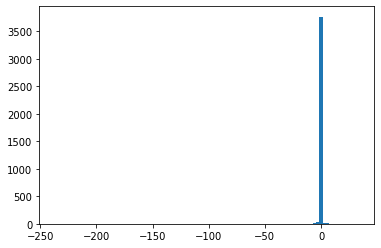

In [23]:
#案例:数据清洗
#检查ROE的分布情况
plt.hist(df_roe.dropna(),bins=100)
plt.show()

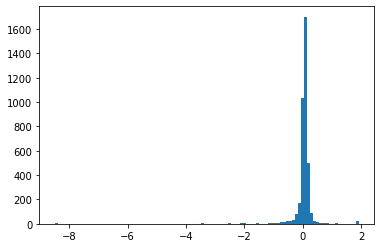

In [24]:
#进行2倍标准差截断处理

df_ = df_roe.dropna().copy()
df_.loc[df_.ROE - df_.ROE.mean() < -2 * df_.ROE.std(), 'ROE'] = df_.ROE.mean() - 2 * df_.ROE.std()
df_.loc[df_.ROE - df_.ROE.mean() > 2 * df_.ROE.std(), 'ROE'] = df_.ROE.mean() + 2 * df_.ROE.std()

plt.hist(df_.ROE,bins=100)
plt.show()

#### 4. LLM 调用

In [25]:
from  openai import OpenAI
import localsetup
import numpy as np
import os

In [26]:
from importlib import reload
reload(localsetup)

<module 'localsetup' from '/data/Codes/人工智能与财务分析/localsetup.py'>

In [80]:

def get_response(prompt):
    # client = OpenAI(
    #     api_key=os.getenv.get(OPENAI_API_KEY), # 如果您没有配置环境变量，请在此处用您的API Key进行替换
    #     base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",  # 填写DashScope服务的base_url
    # )
    client = OpenAI(
        api_key = os.environ.get("LLM_API_KEY"),
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)
    completion = client.chat.completions.create(
        model="qwen-turbo",
        messages=[
            {'role': 'system', 'content': 'You are a helpful assistant.'},
            {'role': 'user', 'content': prompt}],
        temperature=0.8,
        top_p=0.8
        )
    return completion.choices[0].message.content

In [81]:
get_response("你好")

'你好！有什么我可以帮你的吗？'

#### 实践练习
1. 使用米筐 API获取某上市公司近五年财务数据与股价序列
2. 清洗数据并构建基本财务比率表，包含毛利率、净利率、资产负债率等核心指标
3. 调用大语言模型API，输入基础数据，生成一段中文分析报告摘要


In [1]:
from pypdf import PdfReader
import requests
import os

local_pdf_path = "/usr/local/600519_20241026_O2QT.pdf"

# 解析PDF
reader = PdfReader(local_pdf_path)
print(f"✅ PDF总页数：{len(reader.pages)}")
print("\n📄 第一页内容预览：")
print(reader.pages[0].extract_text() + "...")


✅ PDF总页数：11

📄 第一页内容预览：
贵州茅台酒股份有限公司  2024年第三季度报告  
1 / 11 
 证券代码： 600519                                                 证券简称： 贵州茅台  
 
 
贵州茅台酒股份有限公司  
2024年第三季度报告  
 
本公司董事会及全体董事保证本公告内容不存在任何虚假记载、误导性陈述
或者重大遗漏，并对其内容的真实性、准确性和完整性承担法律责任。  
 
重要内容提示：  
公司董事会、监事会及董事、监事、高级管理人员保证季度报告内容的真实、准确、完整，不存
在虚假记载、误导性陈述或重大遗漏，并承担个别和连带的法律责任。  
  
公司负责人 张德芹、主管会计工作负责人 蒋焰及会计机构负责人（会计主管人员） 蔡聪应保证季
度报告中财务 信息的真实、 准确、完整。 
 
第三季度财务报表是否经审计  
□是 √否  
 
 
一、 主要财务数据  
（一） 主要会计数据和财务指标  
单位：元  币种：人民币 
项目 本报告期  本报告期
比上年同
期增减变
动幅度
(%) 年初至报告期末  年初至报告
期末比上年
同期增减变
动幅度(%) 
营业收入  38,845,154,206.94  15.29 120,776,131,874.69  16.95 
归属于上市公司股
东的净利润  19,131,941,135.14  13.23 60,827,552,118.51  15.04 
归属于上市公司股
东的扣除非经常性
损益的净利润  19,108,543,634.77  13.28 60,778,641,454.76  15.08 ...


In [83]:
text=reader.pages[0].extract_text()+reader.pages[1].extract_text()
print(text)

贵州茅台酒股份有限公司  2024年第三季度报告  
1 / 11 
 证券代码： 600519                                                 证券简称： 贵州茅台  
 
 
贵州茅台酒股份有限公司  
2024年第三季度报告  
 
本公司董事会及全体董事保证本公告内容不存在任何虚假记载、误导性陈述
或者重大遗漏，并对其内容的真实性、准确性和完整性承担法律责任。  
 
重要内容提示：  
公司董事会、监事会及董事、监事、高级管理人员保证季度报告内容的真实、准确、完整，不存
在虚假记载、误导性陈述或重大遗漏，并承担个别和连带的法律责任。  
  
公司负责人 张德芹、主管会计工作负责人 蒋焰及会计机构负责人（会计主管人员） 蔡聪应保证季
度报告中财务 信息的真实、 准确、完整。 
 
第三季度财务报表是否经审计  
□是 √否  
 
 
一、 主要财务数据  
（一） 主要会计数据和财务指标  
单位：元  币种：人民币 
项目 本报告期  本报告期
比上年同
期增减变
动幅度
(%) 年初至报告期末  年初至报告
期末比上年
同期增减变
动幅度(%) 
营业收入  38,845,154,206.94  15.29 120,776,131,874.69  16.95 
归属于上市公司股
东的净利润  19,131,941,135.14  13.23 60,827,552,118.51  15.04 
归属于上市公司股
东的扣除非经常性
损益的净利润  19,108,543,634.77  13.28 60,778,641,454.76  15.08 贵州茅台酒股份有限公司  2024年第三季度报告  
2 / 11 
 经营活动产生的现
金流量净额  不适用 不适用 44,421,386,217.45  -11.16 
基本每股收益（元 /
股） 15.23 13.23 48.42 15.04 
稀释每股收益（元 /
股） 15.23 13.23 48.42 15.04 
加权平均净资产收
益率（%） 8.39 增加0.32
个百分点  26.09 增加1.27
个百分点  
 本报告期末  上年度末  本报告期末
比上年度末
增减变动幅
度(%) 
总资产 286,770,722,957.69  272,69

In [84]:
financial_analysis_prompt=f"""
请对下面公司的财务报表进行分析：

{text}


"""

In [86]:
response=get_response(financial_analysis_prompt)

In [88]:
print(response)

根据您提供的贵州茅台酒股份有限公司（证券代码：600519）2024年第三季度财务报表，以下是对该季度财务数据的分析与解读：

---

### 一、核心财务指标概览

| 项目 | 本报告期（2024年7-9月） | 年初至报告期末（2024年1-9月） |
|------|-------------------------|-------------------------------|
| 营业收入 | 38,845,154,206.94 元 | 120,776,131,874.69 元 |
| 净利润（归属于上市公司股东） | 19,131,941,135.14 元 | 60,827,552,118.51 元 |
| 扣非净利润 | 19,108,543,634.77 元 | 60,778,641,454.76 元 |
| 基本每股收益 | 15.23 元/股 | 48.42 元/股 |
| 加权平均净资产收益率 | 8.39% | 26.09% |

---

### 二、关键财务数据分析

#### 1. **营业收入**
- **本季度**：388.45亿元，同比增长15.29%
- **前三季度累计**：1207.76亿元，同比增长16.95%

**分析**：
- 贵州茅台在2024年第三季度继续保持稳健增长，营收增速稳定，显示出其品牌价值和市场占有率的持续提升。
- 高端白酒行业整体景气度较高，公司作为行业龙头，受益于消费升级和高端需求的增加。

#### 2. **净利润**
- **本季度**：191.32亿元，同比增长13.23%
- **前三季度累计**：608.28亿元，同比增长15.04%

**分析**：
- 净利润增速略低于营收增速，可能受到成本上升或运营费用增加的影响，但整体仍保持较高盈利水平。
- 扣非净利润与净利润几乎持平，说明公司非经常性损益影响较小，主营业务盈利能力强劲。

#### 3. **每股收益**
- **本季度**：15.23元/股，同比增长13.23%
- **前三季度**：48.42元/股，同比增长15.04%

**分析**：
- 每股收益持续增长，表明公司为股东创造的价值不断提高。
- 高每股收益也反映出公司在高端市场的定价能力和品牌溢价能力。

#### 4. **净资产收益率（ROE）**
- *